In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [18]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),    #이미지를 28x28 크기로 통일
    transforms.Grayscale(1),        #흑백 이미지로 변환(도형만 컬러 필요없음)
    transforms.RandomInvert(1),        #이미지 색상 반전  
    transforms.ToTensor(),          
    transforms.Normalize((0.5,), (0.5,))
])

In [19]:
train_path = './shape/train'
test_path = './shape/test'
train_dataset = torchvision.datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_path, transform=transform)

len(train_dataset), len(test_dataset)

# (240, 60)

(240, 60)

In [20]:
train_dataset.__getitem__(10)  # 첫 번째 이미지와 레이블 확인
# (tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
#           [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
#           [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
#            -1.0000, -1.0000, -1.0000, -0.8196, -0.4824, -0.4431, -0.4353,
#            -0.4353, -0.4431, -0.4353, -0.4353, -0.4431, -0.9294, -1.0000,
#            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],

(tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.000

In [21]:
train_dataset.classes, test_dataset.classes

# (['cir', 'tri', 'x'], ['cir', 'tri', 'x'])

(['cir', 'tri', 'x'], ['cir', 'tri', 'x'])

In [22]:
class_map = {
    0:'cir',
    1:'tri',
    2:'x'
}

In [23]:
loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

imgs, labels = next(iter(loader))
print(imgs.shape)  # torch.Size([16, 1, 28, 28])

torch.Size([64, 1, 28, 28])


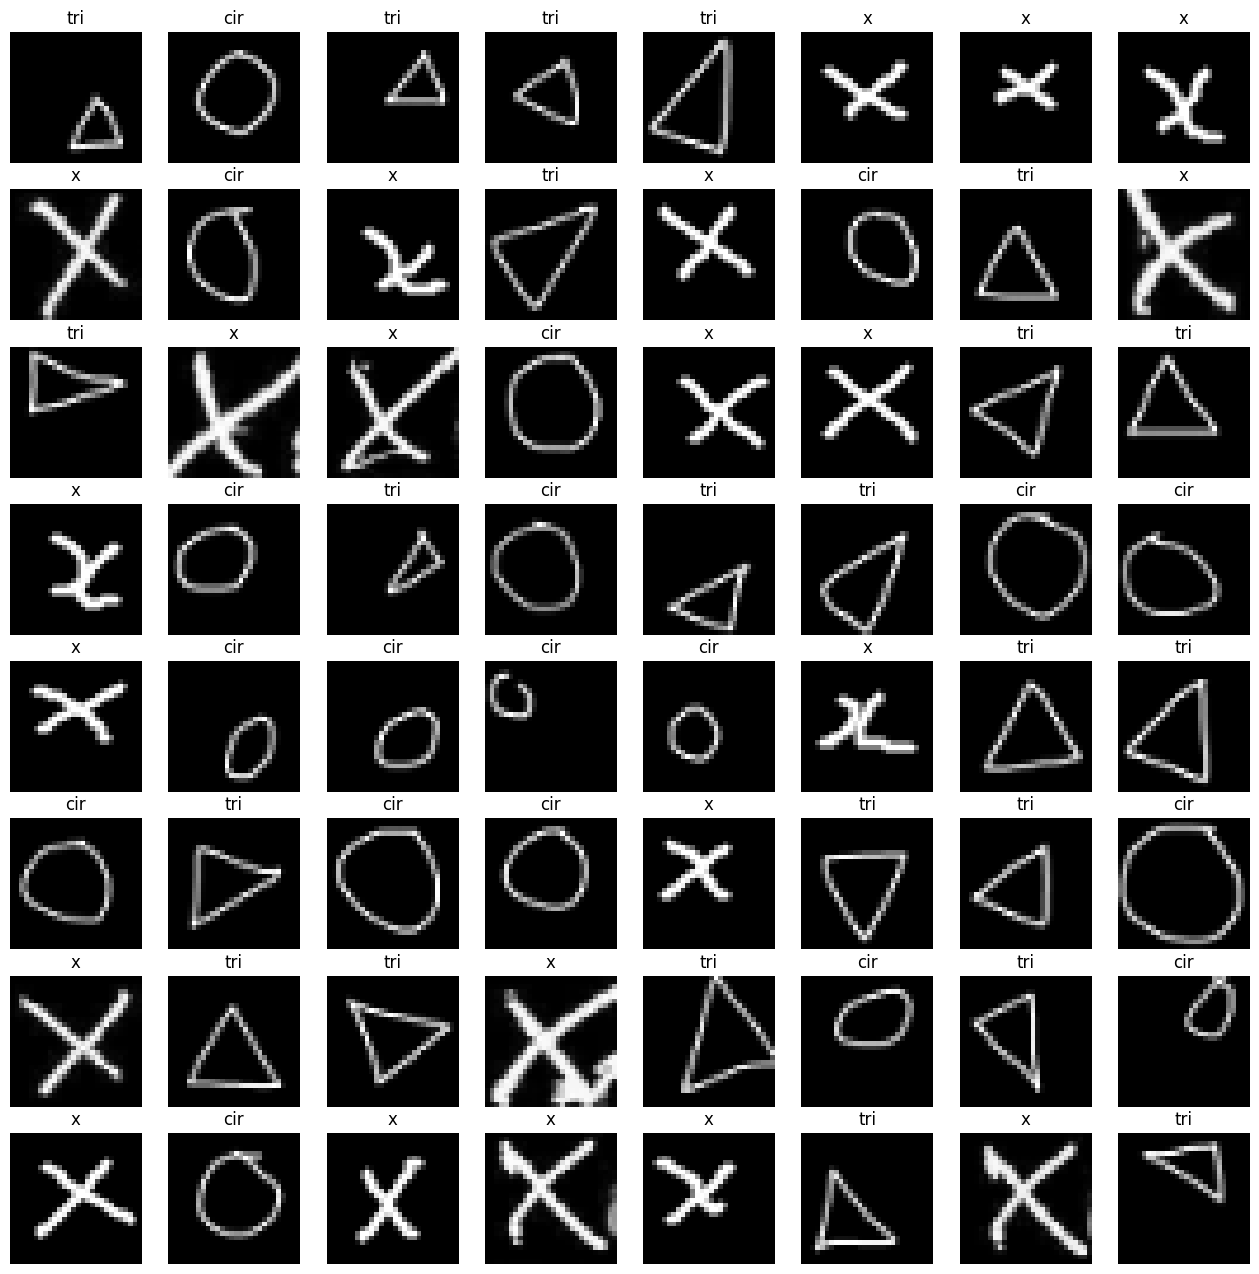

In [24]:
fig, axes = plt.subplots(8, 8, figsize=(16, 16))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(class_map[label.item()])
    ax.axis('off')

In [25]:
# 장치 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [ ]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super(ConvNeuralNetwork, self).__init__()   
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Conv2d(1, 28, kernel_size=3, padding = 'same'), #합성곱 층 1>28
            nn.ReLU(),  #비선형을 살려주는 활성화 함수
            nn.Conv2d(28, 28, kernel_size=3, padding = 'same'),#합성곱 층 28>28
            #이미지를 2번씩 연속으로 봐주어 특징을 더 잘 잡아낼 수 있도록 함
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  #다운샘플링
            nn.Dropout(0.25),  #과적합 방지

            nn.Conv2d(28, 56, kernel_size=3, padding = 'same'), #합성곱 층 28>56
            nn.ReLU(),
            nn.Conv2d(56, 56, kernel_size=3, padding = 'same'), #합성곱 층 56>56
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  #다운샘플링
            nn.Dropout(0.25),  #과적합 방지
        )
        self.Linear = nn.Linear(56*7*7, 3) #56*7*7개의 특징을 3개의 클래스로 분류

    def forward(self, x):
        x = self.classifier(x)  #특징 추출 부분
        x = self.flatten(x)     #평탄화
        output = self.Linear(x)      #분류 부분
        return output

In [27]:
model = ConvNeuralNetwork().to(device)
model

# ConvNeuralNetwork(
#   (flatten): Flatten(start_dim=1, end_dim=-1)
#   (classifier): Sequential(
#     (0): Conv2d(1, 28, kernel_size=(3, 3), stride=(1, 1), padding=same)
#     (1): ReLU()
#     (2): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=same)
#     (3): ReLU()
#     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (5): Dropout(p=0.25, inplace=False)
#     (6): Conv2d(28, 56, kernel_size=(3, 3), stride=(1, 1), padding=same)
#     (7): ReLU()
#     (8): Conv2d(56, 56, kernel_size=(3, 3), stride=(1, 1), padding=same)
#     (9): ReLU()
#     (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (11): Dropout(p=0.25, inplace=False)
#   )
#   (Linear): Linear(in_features=2744, out_features=3, bias=True)
# )

ConvNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Conv2d(1, 28, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Conv2d(28, 56, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (7): ReLU()
    (8): Conv2d(56, 56, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.25, inplace=False)
  )
  (Linear): Linear(in_features=2744, out_features=3, bias=True)
)

In [28]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_loop(loader, model, loss_fn, optimizer):
    sum_losses = 0
    sum_accs = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)   #배치 데이터 장치로 이동
        y_pred = model(X_batch)         #모델 예측값 계산
        loss = loss_fn(y_pred, y_batch) #손실 계산
        optimizer.zero_grad()       
        loss.backward()             #역전파 수행
        optimizer.step()            
        sum_losses += loss.item()       #배치 손실 누적
        y_prob = nn.Softmax(1)(y_pred) # 열끼리의 확률로 변환
        y_pred_index = torch.argmax(y_prob, axis=1) #가장 높은 확률의 인덱스를 예측 레이블로 사용
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100 #배치 정확도 계산
        sum_accs += acc.item()         #배치 정확도 누적

    avg_loss = sum_losses / len(loader)  #평균 손실 계산
    avg_acc = sum_accs / len(loader)        #평균 정확도 계산
    return avg_loss, avg_acc

In [29]:
epochs = 50

for i in range(epochs):
    print(f'Epoch {i+1}/{epochs}')
    avg_loss, avg_acc = train_loop(loader, model, loss, optimizer)  
    print(f'Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.2f}%\n')

Epoch 1/50
Loss: 1.0921, Accuracy: 35.16%

Epoch 2/50
Loss: 1.0250, Accuracy: 64.97%

Epoch 3/50
Loss: 0.7813, Accuracy: 76.43%

Epoch 4/50
Loss: 0.5113, Accuracy: 72.66%

Epoch 5/50
Loss: 0.4201, Accuracy: 75.39%

Epoch 6/50
Loss: 0.4075, Accuracy: 79.17%

Epoch 7/50
Loss: 0.3525, Accuracy: 80.34%

Epoch 8/50
Loss: 0.3579, Accuracy: 83.07%

Epoch 9/50
Loss: 0.3220, Accuracy: 86.20%

Epoch 10/50
Loss: 0.2810, Accuracy: 87.89%

Epoch 11/50
Loss: 0.2436, Accuracy: 89.19%

Epoch 12/50
Loss: 0.2424, Accuracy: 89.71%

Epoch 13/50
Loss: 0.1907, Accuracy: 91.02%

Epoch 14/50
Loss: 0.1920, Accuracy: 90.76%

Epoch 15/50
Loss: 0.1642, Accuracy: 92.58%

Epoch 16/50
Loss: 0.2204, Accuracy: 89.84%

Epoch 17/50
Loss: 0.2655, Accuracy: 86.33%

Epoch 18/50
Loss: 0.1627, Accuracy: 92.84%

Epoch 19/50
Loss: 0.1395, Accuracy: 94.53%

Epoch 20/50
Loss: 0.1067, Accuracy: 96.88%

Epoch 21/50
Loss: 0.1127, Accuracy: 95.70%

Epoch 22/50
Loss: 0.0985, Accuracy: 98.18%

Epoch 23/50
Loss: 0.0852, Accuracy: 96.88

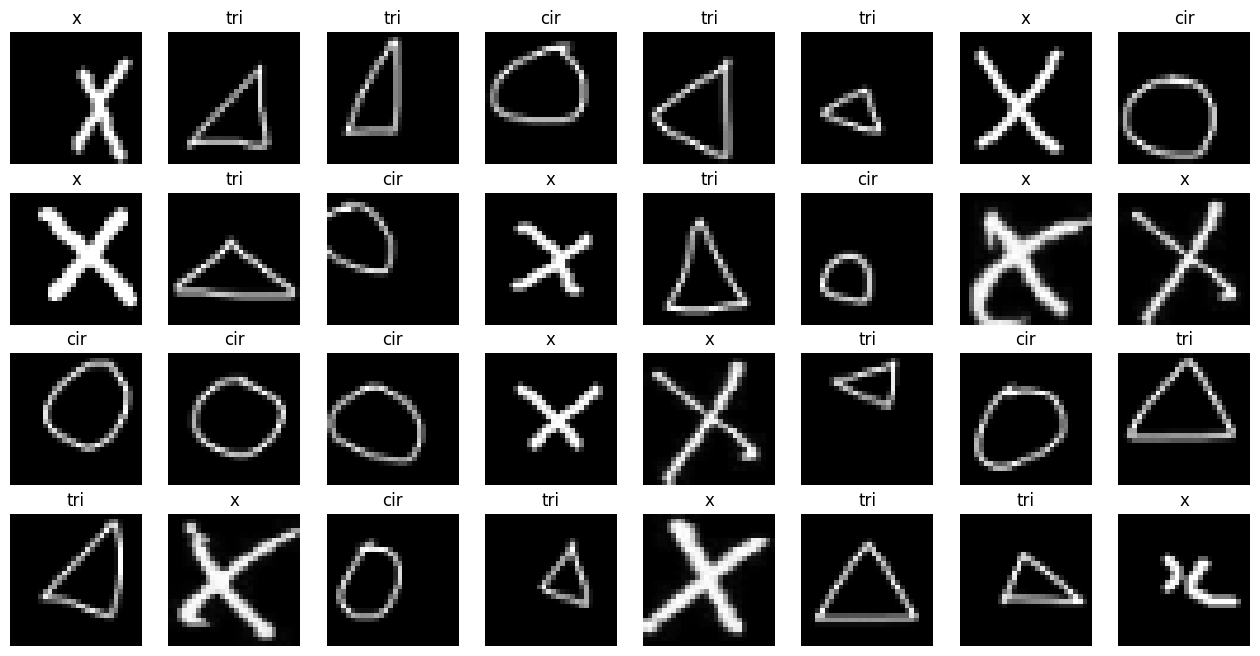

In [30]:
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

imgs, labels = next(iter(test_loader))


imgs, labels = next(iter(test_loader))
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(class_map[label.item()])
    ax.axis('off')

In [31]:
def test(model, loader):
    model.eval()  #평가 모드로 전환(추론으로 돈다)
    sum_accs = 0

    img_list = torch.Tensor().to(device)
    y_pred_list = torch.Tensor().to(device)
    y_true_list = torch.Tensor().to(device)
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        y_prob = nn.Softmax(1)(y_pred)
        y_pred_index = torch.argmax(y_prob, axis=1) #가장 높은 확률의 인덱스를 예측 레이블로 사용
        y_pred_list = torch.cat((y_pred_list, y_pred_index), dim=0) #행으로 연결
        y_true_list = torch.cat((y_true_list, y_batch), dim=0) 
        img_list = torch.cat((img_list, x_batch), dim=0)  
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100 #배치 정확도 계산 (100%)
        sum_accs += acc
    avg_acc = sum_accs / len(loader)        #평균 정확도 계산
    return y_pred_list, y_true_list, img_list, avg_acc

In [32]:
y_pred_list, y_true_list, img_list, test_acc = test(model, test_loader)
print(f'Test Accuracy: {test_acc:.2f}%')

Test Accuracy: 90.40%


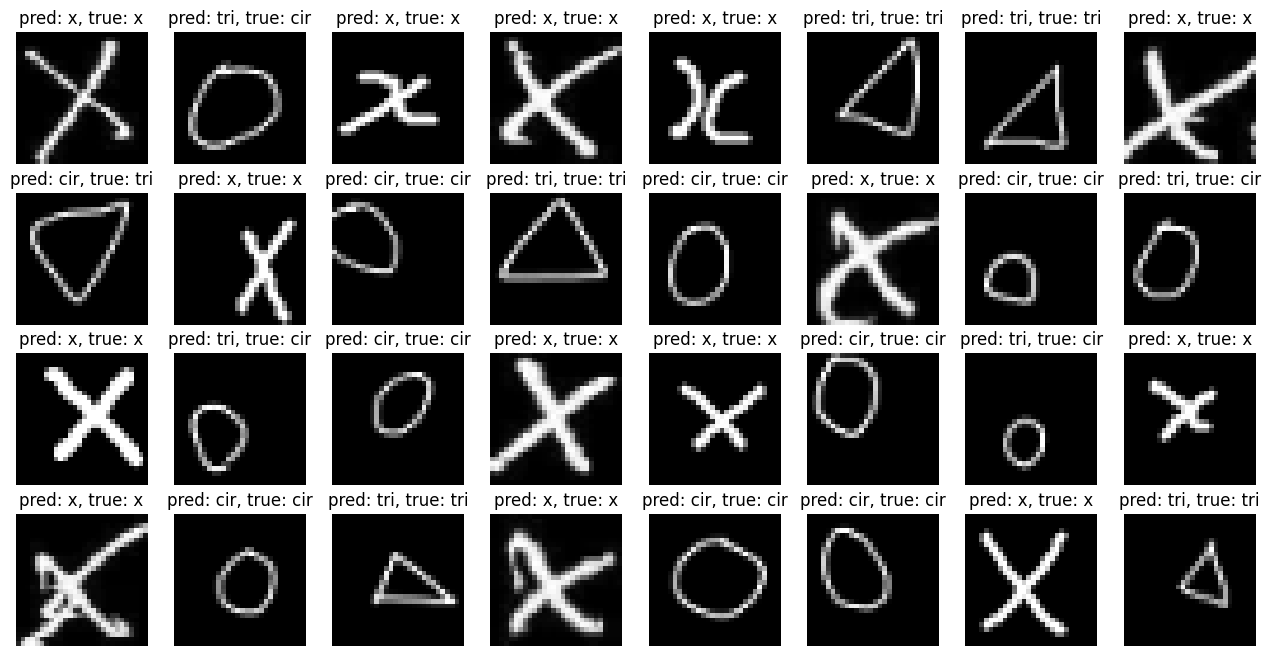

In [33]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

img_list_cpu = img_list.cpu()
y_pred_list_cpu = y_pred_list.cpu()
y_true_list_cpu = y_true_list.cpu()

for ax, img, y_pred, y_true in zip(axes.flatten(), img_list_cpu, y_pred_list_cpu, y_true_list_cpu):
  ax.imshow(img.reshape(28, 28), cmap='gray')
  ax.set_title(f'pred: {class_map[y_pred.item()]}, true: {class_map[y_true.item()]}')
  ax.axis('off')

plt.show()

In [ ]:
#모델의 가중치와 매개변수만 저장
torch.save(model.state_dict(), 'model_weight.pth')#pth: 가중치 저장 확장자

In [ ]:
model2 = ConvNeuralNetwork().to(device)#학습이 안된 껍데기 모델

y_pred_list2, y_true_list2, img_list2, test_acc2 = test(model2, test_loader)
print(f'Test Accuracy (before loading weights): {test_acc2:.2f}%')

# Test Accuracy (before loading weights): 33.26%

Test Accuracy (before loading weights): 33.26%


In [ ]:
model2.load_state_dict(torch.load('model_weight.pth'))#가중치 불러오기
y_pred_list2, y_true_list2, img_list2, test_acc2 = test(model2, test_loader)
print(f'Test Accuracy (after loading weights): {test_acc2:.2f}%')

# Test Accuracy (after loading weights): 89.96%

Test Accuracy (after loading weights): 89.96%


In [40]:
torch.save(model, 'model_full.pth')#모델 전체 저장

In [ ]:
model3 = torch.load('model_full.pth', weights_only=False)#모델 전체 불러오기
y_pred_list3, y_true_list3, img_list3, test_acc3 = test(model3, test_loader)
print(f'Test Accuracy (after loading full model): {test_acc3:.2f}%')

# Test Accuracy (after loading full model): 89.96%

Test Accuracy (after loading full model): 89.51%
